# Phase 4a — Band T native-unit choropleths

Visual EDA of LMR v2.1 and HYDE 3.4 at their native grids. No spatial statistics — maps only.

**LMR**: temperature anomaly + PDSI at 6 epochs (0 CE, 1000 CE, 1500 CE, 1900 CE, MCA, LIA).  
**HYDE**: cropland + grazing_land at 8 epochs (−8000 to 2000 CE), native 5-arcmin from DB.

Data access: `temporal.lmr_climate` (16,380 cells, arrays length 2001 = grand ensemble mean);  
`temporal.hyde_cells` (2,215,829 land cells, epoch values via SQL subscript).

LMR land mask for 4b (not used in visual EDA): L8-basin-bearing cells (~5,000).

In [21]:
# Cell 2 — imports and output setup
import ssl
import certifi
import urllib.request

# macOS Python 3.14: default opener captures SSL context at startup before
# certifi is loaded. Replace the global opener with one using certifi certs
# so Cartopy can download Natural Earth shapefiles.
_ssl_ctx = ssl.create_default_context(cafile=certifi.where())
urllib.request.install_opener(
    urllib.request.build_opener(urllib.request.HTTPSHandler(context=_ssl_ctx))
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import netCDF4 as nc
from pathlib import Path
import sys
import time as _time

sys.path.insert(0, "/Users/karlg/Documents/repos/_cedop")
from scripts.shared.db_utils import db_connect

%matplotlib inline

LMR_DIR = Path("/Users/karlg/Documents/repos/_cedop/data/lmr_v2.1")
OUT_DIR = Path("/Users/karlg/Documents/repos/_cedop/output/edop/spatial")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("Output:", OUT_DIR)

Output: /Users/karlg/Documents/repos/_cedop/output/edop/spatial


In [3]:
# Cell 3 — epoch definitions

# LMR: (label, year_lo, year_hi) — centennial windows + climate periods
# Anomalies relative to full 0-1998 CE mean
LMR_EPOCHS = [
    ("0 CE (early-LMR)",  0,    49),    # first 50 years only; low fidelity per F10.1
    ("1000 CE",           950,  1049),
    ("1500 CE",           1450, 1549),
    ("1900 CE",           1850, 1949),
    ("MCA 950–1250",      950,  1250),
    ("LIA 1450–1850",     1450, 1850),
]

# HYDE: (step_idx 0-based, label)
# SQL subscript = step_idx + 1 (PostgreSQL 1-indexed arrays)
# Verified from temporal.hyde_times
HYDE_EPOCHS = [
    (2,   "8000 BCE"),
    (6,   "4000 BCE"),
    (9,   "1000 BCE"),
    (10,  "0 CE"),
    (20,  "1000 CE"),
    (25,  "1500 CE"),
    (47,  "1900 CE"),
    (102, "2000 CE"),
]

# Zoom regions for regional detail panels: (name, lon_lo, lon_hi, lat_lo, lat_hi)
ZOOM_REGIONS = [
    ("Fertile Crescent",  30,  60, 25, 45),
    ("North China Plain", 100, 125, 25, 45),
    ("Mesoamerica",      -100, -75, 10, 25),
]
ZOOM_STEP_IDXS = [20, 47, 102]   # 1000 CE, 1900 CE, 2000 CE
ZOOM_LABELS    = {20: "1000 CE", 47: "1900 CE", 102: "2000 CE"}

In [4]:
# Cell 4 — load LMR time axis from NC (lightweight: time variable only)
ds = nc.Dataset(LMR_DIR / "pdsi_MCruns_ensemble_mean_LMRv2.1.nc")
time_var = ds.variables["time"]
times = nc.num2date(time_var[:], time_var.units, has_year_zero=True)
LMR_YEARS = np.array([t.year for t in times])   # shape (2001,)
ds.close()

print(f"LMR time axis: {len(LMR_YEARS)} steps, {LMR_YEARS[0]}–{LMR_YEARS[-1]} CE")
for check_yr in [0, 950, 1000, 1450, 1850, 1900]:
    idxs = np.where(LMR_YEARS == check_yr)[0]
    print(f"  year {check_yr} CE → index {idxs[0] if len(idxs) else 'NOT FOUND'}")

/var/folders/f9/r5mr431d23zcpktsjz_xjxt40000gn/T/ipykernel_4229/3178310514.py:4: CFWarning: this date/calendar/year zero convention is not supported by CF
  times = nc.num2date(time_var[:], time_var.units, has_year_zero=True)


In [5]:
# Cell 5 — load LMR data from DB
# temporal.lmr_climate: lat, lon, pdsi real[], air real[]  (2001 elements = grand ensemble mean)
t0 = _time.time()
conn = db_connect()
lmr_df = pd.read_sql("""
    SELECT lat, lon, pdsi, air
    FROM temporal.lmr_climate
    ORDER BY lat DESC, lon ASC
""", conn)
conn.close()
print(f"LMR rows: {len(lmr_df):,}  in {_time.time()-t0:.1f}s")
print(f"pdsi array length: {len(lmr_df['pdsi'].iloc[0])}")
print(f"air  array length: {len(lmr_df['air'].iloc[0])}")
print(f"lat range: {lmr_df['lat'].min()} – {lmr_df['lat'].max()}")
print(f"lon range: {lmr_df['lon'].min()} – {lmr_df['lon'].max()}")

LMR rows: 16,380  in 16.3s
pdsi array length: 2001
air  array length: 2001
lat range: -90.0 – 90.0
lon range: 0.0 – 358.0


In [6]:
# Cell 6 — verify arrays and reshape to 3D grid (lat, lon, time)
t0 = _time.time()
pdsi_all = np.array(lmr_df["pdsi"].tolist(), dtype=np.float32)  # (16380, 2001)
air_all  = np.array(lmr_df["air"].tolist(),  dtype=np.float32)  # (16380, 2001)
print(f"Array conversion: {_time.time()-t0:.1f}s")
print(f"pdsi_all shape: {pdsi_all.shape}")

# Sanity check: air is a temperature anomaly field → values should be small (|<5 K)
print(f"\nair stats: mean={np.nanmean(air_all):.4f} K  std={np.nanstd(air_all):.4f} K")
print(f"air range: {np.nanmin(air_all):.3f} to {np.nanmax(air_all):.3f} K")
print(f"pdsi range: {np.nanmin(pdsi_all):.2f} to {np.nanmax(pdsi_all):.2f}")

# Reshape: ORDER BY lat DESC, lon ASC → rows fill lat=90 first, then lat=88, …
lats_lmr = np.sort(lmr_df["lat"].unique())[::-1]   # 90 → -90, 91 values
lons_lmr = np.sort(lmr_df["lon"].unique())          # 0 → 358, 180 values
NLAT, NLON = len(lats_lmr), len(lons_lmr)
print(f"\nGrid: {NLAT} lat × {NLON} lon")

pdsi_grid = pdsi_all.reshape(NLAT, NLON, len(LMR_YEARS))  # (91, 180, 2001)
air_grid  = air_all.reshape(NLAT, NLON, len(LMR_YEARS))
print(f"pdsi_grid: {pdsi_grid.shape}  air_grid: {air_grid.shape}")

Array conversion: 0.7s
pdsi_all shape: (16380, 2001)

air stats: mean=-0.1515 K  std=0.3453 K
air range: -6.089 to 4.182 K
pdsi range: -6.85 to 6.44

Grid: 91 lat × 180 lon
pdsi_grid: (91, 180, 2001)  air_grid: (91, 180, 2001)


In [7]:
# Cell 7 — compute LMR epoch anomaly slices
# Anomaly = epoch-window mean − full 0–1998 CE mean (per cell)
air_full  = np.nanmean(air_grid,  axis=2)   # (91, 180)
pdsi_full = np.nanmean(pdsi_grid, axis=2)   # (91, 180)

def epoch_anomaly(grid3d, full_mean, year_lo, year_hi):
    mask = (LMR_YEARS >= year_lo) & (LMR_YEARS <= year_hi)
    n = mask.sum()
    ep_mean = np.nanmean(grid3d[:, :, mask], axis=2)
    return ep_mean - full_mean, n

air_epochs, pdsi_epochs, n_steps = [], [], []
for label, yr_lo, yr_hi in LMR_EPOCHS:
    a_anom, na = epoch_anomaly(air_grid,  air_full,  yr_lo, yr_hi)
    p_anom, _  = epoch_anomaly(pdsi_grid, pdsi_full, yr_lo, yr_hi)
    air_epochs.append(a_anom)
    pdsi_epochs.append(p_anom)
    n_steps.append(na)
    print(f"{label} ({na} steps): air anom mean={np.nanmean(a_anom):.4f} K  "
          f"pdsi anom mean={np.nanmean(p_anom):.4f}")

# LMR lons run 0-358; roll 90 cols so display runs -180 to 178° for PlateCarree
def center_lmr(arr2d):
    return np.roll(arr2d, 90, axis=1)

0 CE (early-LMR) (51 steps): air anom mean=0.0712 K  pdsi anom mean=-0.0031
1000 CE (100 steps): air anom mean=-0.0226 K  pdsi anom mean=0.0062
1500 CE (101 steps): air anom mean=-0.0913 K  pdsi anom mean=0.0024
1900 CE (100 steps): air anom mean=-0.0425 K  pdsi anom mean=-0.0152
MCA 950–1250 (301 steps): air anom mean=-0.0372 K  pdsi anom mean=0.0033
LIA 1450–1850 (402 steps): air anom mean=-0.1142 K  pdsi anom mean=-0.0013


In [29]:
# Cell 8 — LMR per-epoch single-map writer (Mollweide)
# Mollweide: equal-area oval — pcolormesh transforms 16k grid points, not pixels.
# imshow + transform on non-PlateCarree axes rasterizes every output pixel; avoid it.
_lons_c = np.arange(-180, 180, 2)
_lats_c = np.arange(90, -92, -2)
_LONS_2D, _LATS_2D = np.meshgrid(_lons_c, _lats_c)
_EPOCH_SLUGS = ["0ce", "1000ce", "1500ce", "1900ce", "mca", "lia"]

def plot_lmr_epochs(epoch_arrays, var_label, unit_label, cmap, vmax, subfolder, file_prefix):
    """Write one Mollweide PNG per epoch to output/edop/spatial/<subfolder>/."""
    out = OUT_DIR / subfolder
    out.mkdir(exist_ok=True)
    norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    proj = ccrs.Mollweide()
    labels = [lbl for lbl, _, _ in LMR_EPOCHS]
    for arr, label, slug in zip(epoch_arrays, labels, _EPOCH_SLUGS):
        fig, ax = plt.subplots(figsize=(12, 5), subplot_kw={"projection": proj})
        ax.set_global()
        ax.add_feature(cfeature.LAND, facecolor="#f0f0f0", zorder=0)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor="#444")
        im = ax.pcolormesh(
            _LONS_2D, _LATS_2D, center_lmr(arr),
            transform=ccrs.PlateCarree(),
            cmap=cmap, norm=norm, shading="nearest",
        )
        ax.set_title(
            f"LMR v2.1 — {var_label}  |  {label}\n"
            "Anomaly vs 0–1998 CE mean  ·  spatial structure via LMR Bayesian reanalysis (CCSM4-LME prior)",
            fontsize=9,
        )
        cb = plt.colorbar(im, ax=ax, orientation="vertical", fraction=0.025, pad=0.02)
        cb.set_label(unit_label)
        fname = f"{file_prefix}_{slug}.png"
        plt.savefig(out / fname, dpi=150)
        print(f"  {subfolder}/{fname}")
    print(f"Done — {len(epoch_arrays)} maps → {out}")

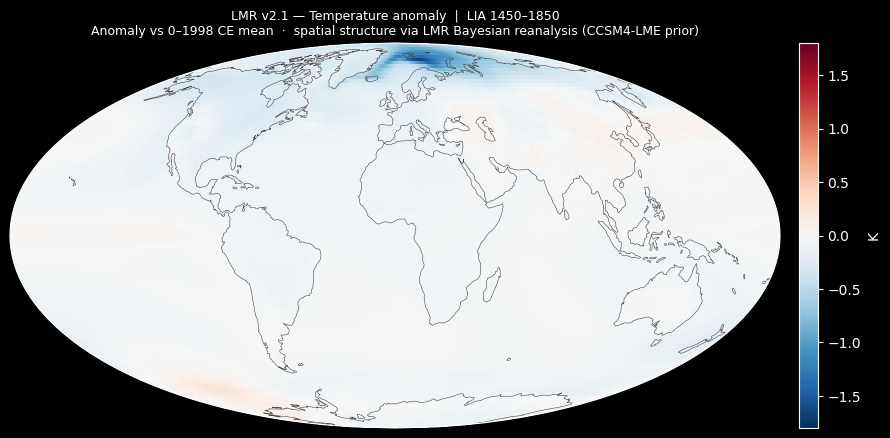

In [31]:
# Cell 9 — LMR temperature: per-epoch maps
air_max = max(np.nanmax(np.abs(a)) for a in air_epochs)
vmax_air = max(0.4, round(air_max * 1.1, 1))
print(f"air anomaly absolute max: {air_max:.3f} K  →  vmax_air={vmax_air}")

plot_lmr_epochs(air_epochs, "Temperature anomaly", "K", "RdBu_r", vmax_air,
                "lmr_temperature", "temperature")

In [33]:
# Cell 9b — LMR temperature: regional means → CSV + print
# Written to disk so findings can reference numbers without re-running.
labels = [lbl for lbl, _, _ in LMR_EPOCHS]
rows = []
for lbl, arr in zip(labels, air_epochs):
    rows.append({
        "epoch":   lbl,
        "NH":      round(float(np.nanmean(arr[:46, :])),  4),   # lat 90→2°
        "SH":      round(float(np.nanmean(arr[46:, :])),  4),   # lat 0→-90°
        "Arctic":  round(float(np.nanmean(arr[:13, :])),  4),   # lat 90→66°
        "Tropics": round(float(np.nanmean(arr[34:46, :])), 4),  # lat 22→0°
    })

df_means = pd.DataFrame(rows)
out_csv = OUT_DIR / "lmr_temperature_regional_means.csv"
df_means.to_csv(out_csv, index=False)
print(f"Saved {out_csv}\n")
print(df_means.to_string(index=False))

Saved /Users/karlg/Documents/repos/_cedop/output/edop/spatial/lmr_temperature_regional_means.csv

           epoch      NH      SH  Arctic  Tropics
0 CE (early-LMR)  0.1398  0.0010  0.2550   0.0513
         1000 CE -0.0491  0.0046 -0.0359  -0.0374
         1500 CE -0.1502 -0.0310 -0.3920  -0.0310
         1900 CE -0.0020 -0.0840  0.0024  -0.0404
    MCA 950–1250 -0.0680 -0.0056 -0.0986  -0.0449
   LIA 1450–1850 -0.1858 -0.0410 -0.4659  -0.0433


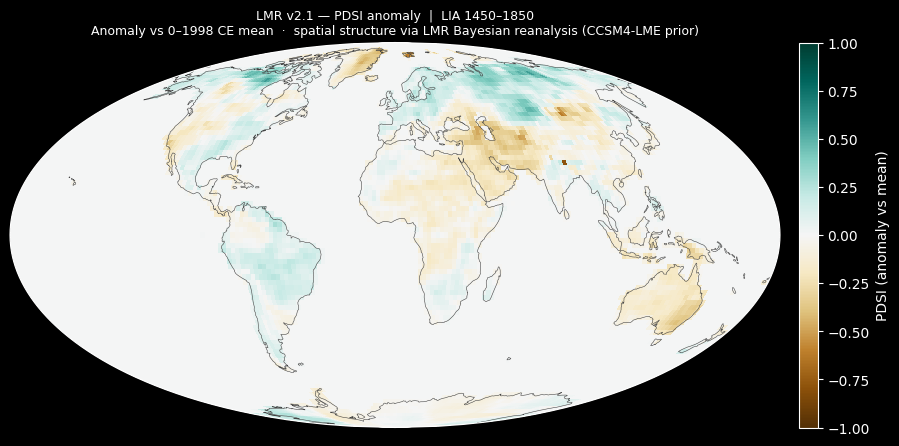

In [34]:
# Cell 10 — LMR PDSI: per-epoch maps
pdsi_max = max(np.nanmax(np.abs(p)) for p in pdsi_epochs)
vmax_pdsi = max(0.5, round(pdsi_max * 1.1, 1))
print(f"PDSI anomaly absolute max: {pdsi_max:.3f}  →  vmax_pdsi={vmax_pdsi}")

# BrBG: brown = dry (negative PDSI anomaly), teal/green = wet (positive)
plot_lmr_epochs(pdsi_epochs, "PDSI anomaly", "PDSI (anomaly vs mean)", "BrBG", vmax_pdsi,
                "lmr_pdsi", "pdsi")

In [35]:
# Cell 10b — LMR PDSI: regional means → CSV + print
rows = []
for lbl, arr in zip(labels, pdsi_epochs):
    rows.append({
        "epoch":   lbl,
        "NH":      round(float(np.nanmean(arr[:46, :])),  4),
        "SH":      round(float(np.nanmean(arr[46:, :])),  4),
        "Arctic":  round(float(np.nanmean(arr[:13, :])),  4),
        "Tropics": round(float(np.nanmean(arr[34:46, :])), 4),
    })

df_pdsi = pd.DataFrame(rows)
out_csv = OUT_DIR / "lmr_pdsi_regional_means.csv"
df_pdsi.to_csv(out_csv, index=False)
print(f"Saved {out_csv}\n")
print(df_pdsi.to_string(index=False))

Saved /Users/karlg/Documents/repos/_cedop/output/edop/spatial/lmr_pdsi_regional_means.csv

           epoch      NH      SH  Arctic  Tropics
0 CE (early-LMR)  0.0032 -0.0095  0.0242   0.0052
         1000 CE  0.0045  0.0080 -0.0287   0.0111
         1500 CE  0.0047  0.0002  0.0082  -0.0033
         1900 CE -0.0172 -0.0131  0.0109   0.0028
    MCA 950–1250  0.0012  0.0055 -0.0152   0.0109
   LIA 1450–1850 -0.0012 -0.0015  0.0119  -0.0160


In [36]:
# Cell 11 — load HYDE data from DB
# Query centroid lat/lon + target epoch values via SQL array subscripts
# PostgreSQL 1-indexed: SQL subscript = step_idx + 1

crop_cols = ",\n        ".join(
    [f"cropland[{si+1}] AS crop_{si}" for si, _ in HYDE_EPOCHS]
)
graz_cols = ",\n        ".join(
    [f"grazing[{si+1}]  AS graz_{si}" for si, _ in HYDE_EPOCHS]
)

query = f"""
    SELECT
        ST_X(ST_Centroid(geom)) AS lon,
        ST_Y(ST_Centroid(geom)) AS lat,
        area_km2,
        {crop_cols},
        {graz_cols}
    FROM temporal.hyde_cells
"""

t0 = _time.time()
conn = db_connect()
hyde_df = pd.read_sql(query, conn)
conn.close()
print(f"HYDE rows: {len(hyde_df):,}  in {_time.time()-t0:.1f}s")
print(f"Columns: {list(hyde_df.columns)}")
print(f"area_km2: {hyde_df['area_km2'].min():.4f} – {hyde_df['area_km2'].max():.4f} km²")

HYDE rows: 2,215,829  in 43.8s
Columns: ['lon', 'lat', 'area_km2', 'crop_2', 'crop_6', 'crop_9', 'crop_10', 'crop_20', 'crop_25', 'crop_47', 'crop_102', 'graz_2', 'graz_6', 'graz_9', 'graz_10', 'graz_20', 'graz_25', 'graz_47', 'graz_102']
area_km2: 9.6181 – 85.4797 km²


In [37]:
# Cell 12 — verify HYDE step indexing and non-zero fractions
# 2000 CE (step 102) should dominate; 8000 BCE (step 2) should be near-zero
print(f"{'Epoch':<14} {'step':>5}  {'non-zero cells':>16}  {'non-zero %':>10}  {'total crop km²':>16}")
print("-" * 68)
for si, label in HYDE_EPOCHS:
    col = f"crop_{si}"
    vals = hyde_df[col].values
    vals = np.where(vals < 0, 0.0, vals)   # clip data artefacts
    nz   = int((vals > 0).sum())
    nz_f = 100 * nz / len(vals)
    tot  = vals.sum()
    flag = "  ← DEGENERATE (<5%)" if nz_f < 5 else ""
    print(f"{label:<14} {si:>5}  {nz:>16,}  {nz_f:>9.2f}%  {tot:>16,.0f}{flag}")

Epoch           step    non-zero cells  non-zero %    total crop km²
--------------------------------------------------------------------
8000 BCE           2             6,044       0.27%             1,568  ← DEGENERATE (<5%)
4000 BCE           6           151,509       6.84%            94,513
1000 BCE           9           377,781      17.05%           636,451
0 CE              10           476,490      21.50%         1,404,272
1000 CE           20           578,766      26.12%         1,786,705
1500 CE           25           630,366      28.45%         2,697,254
1900 CE           47           867,706      39.16%         8,764,374
2000 CE          102           985,031      44.45%        14,855,195


In [47]:
# Cell 12b — HYDE epoch stats → CSV + print
# Non-zero fraction and total km² for cropland and grazing at each epoch.
# Written to disk for findings reference without re-running.
rows = []
for si, label in HYDE_EPOCHS:
    crop_vals = np.where(hyde_df[f"crop_{si}"].values < 0, 0.0, hyde_df[f"crop_{si}"].values)
    graz_vals = np.where(hyde_df[f"graz_{si}"].values < 0, 0.0, hyde_df[f"graz_{si}"].values)
    n = len(crop_vals)
    rows.append({
        "epoch":            label,
        "step_idx":         si,
        "crop_nonzero_pct": round(100 * (crop_vals > 0).sum() / n, 2),
        "crop_total_km2":   round(float(crop_vals.sum()), 0),
        "graz_nonzero_pct": round(100 * (graz_vals > 0).sum() / n, 2),
        "graz_total_km2":   round(float(graz_vals.sum()), 0),
    })

df_stats = pd.DataFrame(rows)
out_csv = OUT_DIR / "hyde_epoch_stats.csv"
df_stats.to_csv(out_csv, index=False)
print(f"Saved {out_csv}\n")
print(df_stats.to_string(index=False))

Saved /Users/karlg/Documents/repos/_cedop/output/edop/spatial/hyde_epoch_stats.csv

   epoch  step_idx  crop_nonzero_pct  crop_total_km2  graz_nonzero_pct  graz_total_km2
8000 BCE         2              0.27          1568.0              1.35          9493.0
4000 BCE         6              6.84         94513.0             18.85        253602.0
1000 BCE         9             17.05        636451.0             31.77       1029612.0
    0 CE        10             21.50       1404272.0             36.87       1702526.0
 1000 CE        20             26.12       1786705.0             39.55       3960351.0
 1500 CE        25             28.45       2697254.0             42.08       5439173.0
 1900 CE        47             39.16       8764374.0             64.16      15561749.0
 2000 CE       102             44.45      14855195.0             58.77      32780945.0


In [38]:
# Cell 13 — rasterize HYDE data to 2D arrays
# HYDE native 5-arcmin: 4320 cols × 2160 rows
# lat descending (90 → -90), lon ascending (-180 → 180)
HYDE_NROW, HYDE_NCOL = 2160, 4320

lons_h = hyde_df["lon"].values
lats_h = hyde_df["lat"].values
area_h = hyde_df["area_km2"].values

row_idx = np.clip(np.round((90.0  - lats_h) * 12).astype(int), 0, HYDE_NROW - 1)
col_idx = np.clip(np.round((lons_h + 180.0) * 12).astype(int), 0, HYDE_NCOL - 1)

# Area raster (denominator for fraction)
area_raster = np.full((HYDE_NROW, HYDE_NCOL), np.nan, dtype=np.float32)
area_raster[row_idx, col_idx] = area_h

def rasterize(col_prefix):
    """Return dict step_idx → 2D fraction array (land-use km² / cell area km²)."""
    grids = {}
    for si, _ in HYDE_EPOCHS:
        col  = f"{col_prefix}_{si}"
        vals = np.where(hyde_df[col].values < 0, 0.0,
                        hyde_df[col].values).astype(np.float32)
        raster = np.full((HYDE_NROW, HYDE_NCOL), np.nan, dtype=np.float32)
        raster[row_idx, col_idx] = vals
        grids[si] = np.clip(raster / area_raster, 0.0, 1.0)
    return grids

t0 = _time.time()
crop_grids = rasterize("crop")
graz_grids = rasterize("graz")
print(f"Rasterization complete in {_time.time()-t0:.1f}s")
print(f"Cropland 2000 CE: max fraction = {np.nanmax(crop_grids[102]):.4f}")
print(f"Grazing  2000 CE: max fraction = {np.nanmax(graz_grids[102]):.4f}")

Rasterization complete in 0.2s
Cropland 2000 CE: max fraction = 1.0000
Grazing  2000 CE: max fraction = 1.0000


In [40]:
# Cell 14 — HYDE global choropleth helper (Mollweide)
# Display subsample: every 6th cell → 0.5° (~360×720 = 260k points) for pcolormesh.
# Native arrays remain intact in crop_grids/graz_grids for regional zooms and 4b.
_HYDE_STEP = 6
_hyde_lons_d = np.linspace(-180 + 1/24, 180 - 1/24, 4320)[::_HYDE_STEP]
_hyde_lats_d = np.linspace(90 - 1/24, -90 + 1/24, 2160)[::_HYDE_STEP]
_HYDE_LONS_D, _HYDE_LATS_D = np.meshgrid(_hyde_lons_d, _hyde_lats_d)

def plot_hyde_global(grids, var_label, subfolder, file_prefix):
    out = OUT_DIR / subfolder
    out.mkdir(exist_ok=True)
    si_2000 = 102
    g2000 = grids[si_2000]
    vmax = float(np.nanpercentile(g2000[g2000 > 0], 99))
    norm = mcolors.LogNorm(vmin=1e-5, vmax=vmax)
    cmap = plt.cm.YlOrBr
    proj = ccrs.Mollweide()
    for si, label in HYDE_EPOCHS:
        fig, ax = plt.subplots(figsize=(12, 5), subplot_kw={"projection": proj})
        ax.set_global()
        ax.add_feature(cfeature.LAND, facecolor="#e8e8e8", zorder=0)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor="#555")
        im = ax.pcolormesh(
            _HYDE_LONS_D, _HYDE_LATS_D, grids[si][::_HYDE_STEP, ::_HYDE_STEP],
            transform=ccrs.PlateCarree(), cmap=cmap, norm=norm, shading="nearest")
        ax.set_title(f"HYDE 3.4 — {var_label}  |  {label}\n"
            "Fraction of cell area (log scale)  ·  native 5-arcmin, display at 0.5°", fontsize=9)
        cb = plt.colorbar(im, ax=ax, orientation="vertical", fraction=0.025, pad=0.02)
        cb.set_label("Fraction of cell area")
        slug = label.lower().replace(" ", "").replace("-", "")
        fname = f"{file_prefix}_{slug}.png"
        plt.savefig(out / fname, dpi=150)
        print(f"  {subfolder}/{fname}")
    print(f"Done — {len(HYDE_EPOCHS)} maps → {out}")
    return vmax

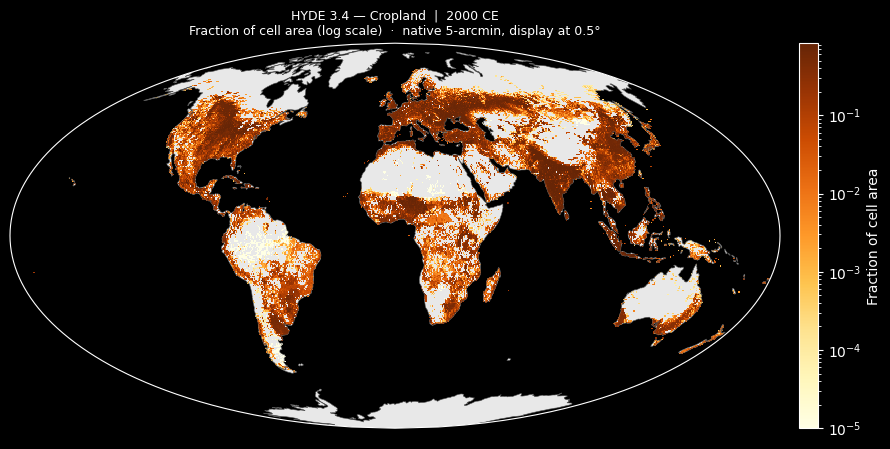

In [41]:
# Cell 15 — HYDE cropland global choropleth
vmax_crop = plot_hyde_global(crop_grids, "Cropland", "hyde_cropland", "cropland")
print(f"Color scale vmax (99th pct at 2000 CE): {vmax_crop:.4f}")

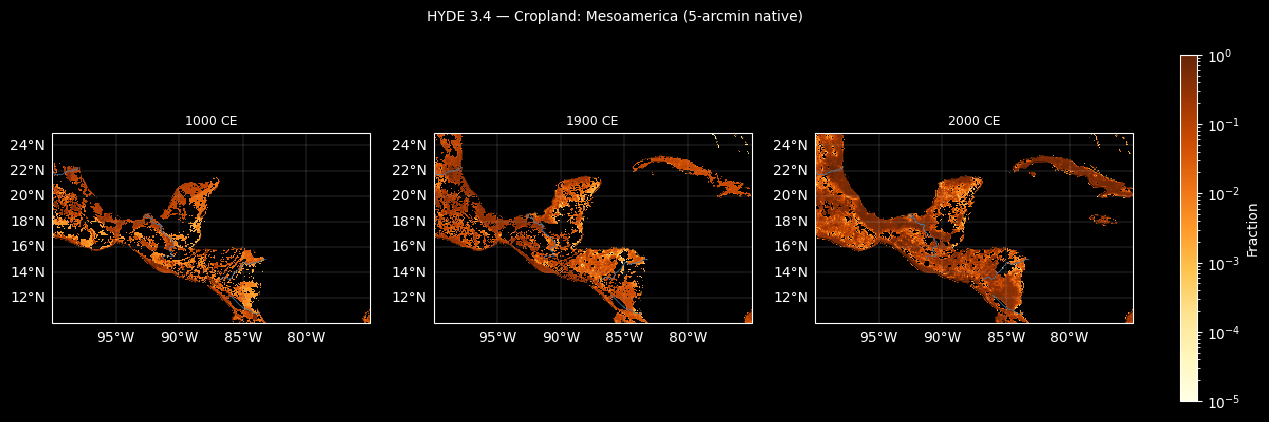

In [45]:
# Cell 16 — HYDE cropland regional zooms
# Native 5-arcmin: subset the 2D array to region to avoid full-globe imshow

def plot_hyde_zoom(grids, region_name, lon_lo, lon_hi, lat_lo, lat_hi,
                   var_label, subfolder, fname):
    out = OUT_DIR / subfolder
    out.mkdir(exist_ok=True)
    step_idxs = ZOOM_STEP_IDXS
    r0 = max(0, int(round((90.0 - lat_hi) * 12)) - 1)
    r1 = min(HYDE_NROW, int(round((90.0 - lat_lo) * 12)) + 2)
    c0 = max(0, int(round((lon_lo + 180.0) * 12)) - 1)
    c1 = min(HYDE_NCOL, int(round((lon_hi + 180.0) * 12)) + 2)
    ext = [lon_lo - 1/12, lon_hi + 1/12, lat_lo - 1/12, lat_hi + 1/12]

    norm = mcolors.LogNorm(vmin=1e-5, vmax=1.0)
    cmap = plt.cm.YlOrBr
    proj = ccrs.PlateCarree()

    fig, axes = plt.subplots(1, len(step_idxs), figsize=(5 * len(step_idxs), 4.5),
                             subplot_kw={"projection": proj})
    im = None
    for ax, si in zip(axes, step_idxs):
        sub = grids[si][r0:r1, c0:c1]
        ax.set_extent([lon_lo, lon_hi, lat_lo, lat_hi], crs=proj)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
        ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=":")
        ax.add_feature(cfeature.RIVERS, linewidth=0.5,
                       edgecolor="steelblue", facecolor="none")
        im = ax.imshow(sub, origin="upper", extent=ext, transform=proj,
                       cmap=cmap, norm=norm, interpolation="nearest")
        ax.set_title(ZOOM_LABELS[si], fontsize=9)
        gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.4)
        gl.top_labels = gl.right_labels = False
    fig.colorbar(im, ax=axes.tolist(), orientation="vertical",
                 fraction=0.03, pad=0.04, label="Fraction")
    fig.suptitle(f"HYDE 3.4 — {var_label}: {region_name} (5-arcmin native)", fontsize=10)
    plt.savefig(out / fname, dpi=150)
    print(f"  {subfolder}/{fname}")

for rname, lon_lo, lon_hi, lat_lo, lat_hi in ZOOM_REGIONS:
    slug = rname.lower().replace(" ", "_")
    plot_hyde_zoom(crop_grids, rname, lon_lo, lon_hi, lat_lo, lat_hi,
                   "Cropland", "hyde_cropland", f"cropland_zoom_{slug}.png")

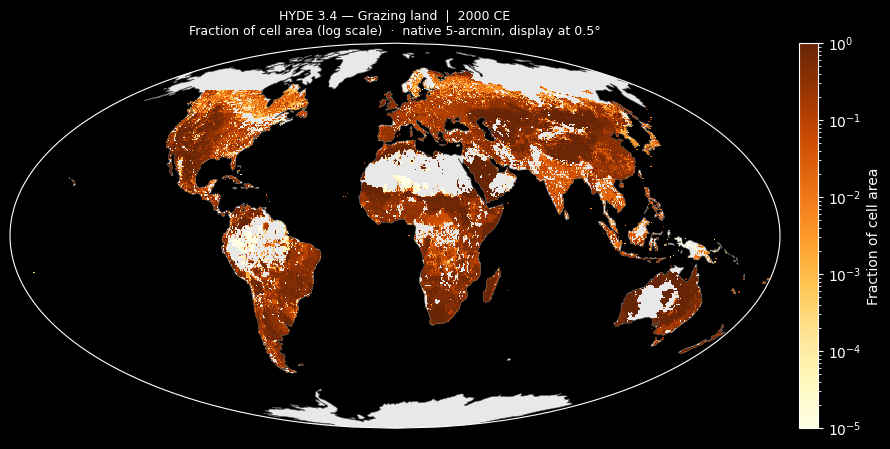

In [43]:
# Cell 17 — HYDE grazing_land global choropleth
vmax_graz = plot_hyde_global(graz_grids, "Grazing land", "hyde_grazing", "grazing")
print(f"Color scale vmax (99th pct at 2000 CE): {vmax_graz:.4f}")

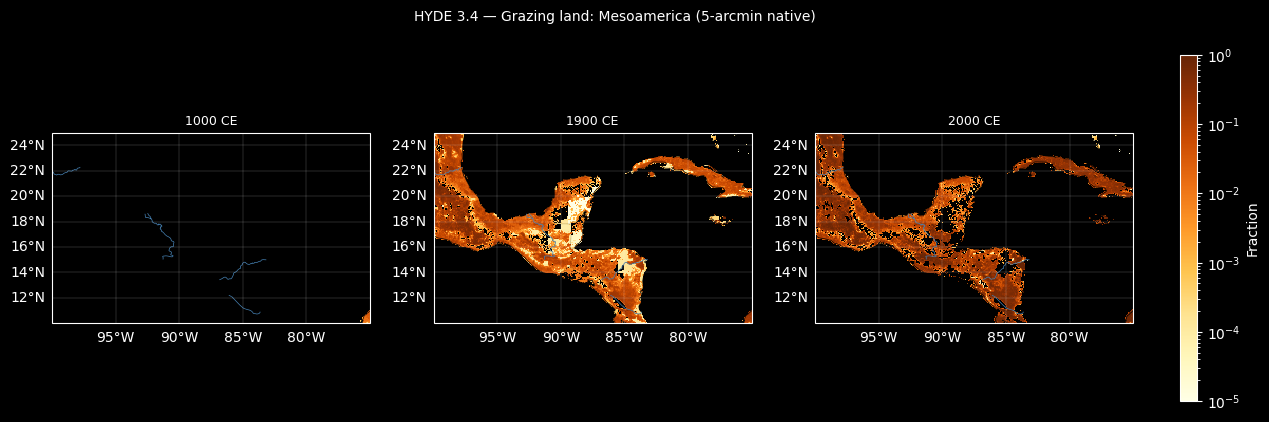

In [46]:
# Cell 18 — HYDE grazing_land regional zooms
for rname, lon_lo, lon_hi, lat_lo, lat_hi in ZOOM_REGIONS:
    slug = rname.lower().replace(" ", "_")
    plot_hyde_zoom(graz_grids, rname, lon_lo, lon_hi, lat_lo, lat_hi,
                   "Grazing land", "hyde_grazing", f"grazing_zoom_{slug}.png")

## Findings — Phase 4a

*Paste into `logs/esda_findings.md` under `## Phase 4 CHAR — Band T native-unit characterization`.*

---

### BT4A.1 — LMR temperature anomaly: epoch maps and regional means

**Date**: 2026-05-22  
**Notebook**: `16a_band_t_native_choropleths.ipynb`  
**Method**: Grand ensemble mean (20 MCruns collapsed in DB), centennial-window anomaly relative to full 0–1998 CE mean. 2° native grid, 16,380 cells, Mollweide projection. Regional means in `lmr_temperature_regional_means.csv`.

**Baseline caveat (first-class)**: The reference mean is LMR's own 0–1998 CE reconstruction, which includes ~100 years of industrial-era warming. All pre-industrial epochs therefore appear negative or near-zero relative to this baseline. Anomalies measure deviation from a partially-industrial mean, not from a pre-industrial normal. Epoch comparisons are relative to each other, not absolute.

**LMR-as-reanalysis caveat (first-class)**: Spatial patterns in these maps reflect the structure of past climate *as seen through the LMR Bayesian reanalysis with its CCSM4-LME model prior*. In proxy-sparse regions and early centuries, the reconstruction defaults toward the model prior's spatial covariance modes. Smooth gradients and confined hotspots may reflect model structure rather than proxy signal. This caveat applies to all epoch maps and all regional mean values.

**Epoch-by-epoch (regional means in K; see CSV for full table):**

- **0 CE (early-LMR)**: NH +0.14, Arctic +0.26 — the largest warm signal in the dataset. Almost certainly an early-LMR artifact: proxy density is lowest in this period (F10.1 funnel effect) and the model prior dominates. Do not interpret as evidence of Roman Warm Period at global scale.

- **1000 CE**: NH −0.05, Arctic −0.04, Tropics −0.04 — uniformly small negative anomalies across all zones; no strong signal. Pre-MCA baseline.

- **MCA 950–1250**: NH −0.07, Arctic −0.10, Tropics −0.04 — **negative throughout, including Arctic**. The visual map shows a small warm patch over Greenland/Iceland, but this is overwhelmed in the Arctic zonal mean by neutral-to-cool conditions elsewhere. The MCA does not register as a warm period relative to the 0–1998 baseline; it is the least-cold pre-industrial epoch after 0 CE, which is a much weaker claim than "Medieval Warm Period." The confined warm patch in the map likely reflects Greenland ice core proxy density rather than broad NH warmth.

- **1500 CE**: NH −0.15, Arctic −0.39, Tropics −0.03 — strong cooling signal; Arctic 2.6× the NH mean. This centennial window sits inside the LIA core.

- **LIA 1450–1850**: NH −0.19, Arctic −0.47, Tropics −0.04 — strongest signal in the dataset. Arctic 2.5× NH. Visual map shows cooling concentrated in a band across subarctic Eurasia (60–75°N), coinciding with the densest tree-ring proxy coverage for this period (Scandinavian and Siberian networks). The LIA cooling in LMR is geographically anchored to the subarctic proxy band, not a uniform NH cooling. Europe proper (30–55°N) shows milder anomalies. SH signal weak (−0.04), consistent with F11.

- **1900 CE** (1850–1949 window): NH ≈ 0, Arctic ≈ 0, SH −0.08. This window straddles the industrial transition. Late-LIA conditions and early warming approximately cancel at the NH zonal mean level, making this the most ambiguous epoch for interpretation.

**Key finding**: The Arctic/NH cooling ratio for LIA (~2.5×) and 1500 CE (~2.6×) is the sharpest pattern in the temperature dataset. It reflects geographic concentration of the cooling signal in subarctic Eurasia, not amplified physical cooling — the LMR proxy network drives the anomaly to where the proxies are. This is a proxy-network bias documented as a first-class LMR limitation.

**SH coherence**: All SH anomalies are ≤ 0.04 K in absolute value except 1900 CE (−0.08). SH signal is weak across all epochs, consistent with F11 and expected from the NH-heavy proxy network.

---

### BT4A.2 — LMR PDSI anomaly: epoch maps and regional means

**Date**: 2026-05-22  
**Notebook**: `16a_band_t_native_choropleths.ipynb`  
**Method**: Same as BT4A.1 for PDSI. BrBG colormap (brown = dry, teal = wet). Regional means in `lmr_pdsi_regional_means.csv`.

**Model-prior caveat (stronger than for temperature)**: PDSI in LMR is a model-derived quantity — it is not directly assimilated from drought proxies but reconstructed via the model's hydrological response to the proxy-constrained temperature and precipitation fields. Spatial patterns in PDSI epoch maps are more model-prior influenced than temperature maps. Interpret geographic patterns as plausible first-order structure, not as established paleoclimate record.

**Regional means are uniformly near-zero**: All PDSI regional means are ≤ 0.03 units across all epochs and zones. The maximum absolute value is 0.029 (1000 CE Arctic). This is the primary quantitative finding: **PDSI has no coherent zonal signal at epoch timescales — the signal is geographic (spatial pattern of wet/dry anomalies), not hemispheric.** Regional-mean summaries are not informative for PDSI; the individual epoch maps carry the content.

**1900 CE exception**: NH −0.017, SH −0.013 — the largest regional values in the table, with both hemispheres showing mild dry anomalies. This window (1850–1949) overlaps with the instrumental record; the signal may reflect real late-LIA drying trends or the model's behavior near the observational boundary.

**LIA PDSI spatial pattern** (from map, Karl's read): SW/Central Asia shows the dominant dry anomaly (orange-brown), extending from the Middle East through Iran/Afghanistan. A dark outlier spot near 32°N 65°E warrants flagging — possible proxy artifact or model singularity. N. Atlantic / northern Europe shows a wet anomaly (teal), consistent with some paleoclimate records of enhanced westerlies during the LIA. Sub-Saharan Africa and parts of South America show wet anomalies. These form a spatially heterogeneous pattern of offsetting regional signals, consistent with the near-zero zonal means.

**MCA vs LIA PDSI**: No clear complementary structure at the zonal-mean level (all means near zero for both). The spatial maps may show regional MCA/LIA contrasts, but these were not quantified in this phase and should be read with the model-prior caveat.

**Relationship to temperature**: PDSI and temperature spatial patterns are geographically distinct. The temperature LIA signal concentrates in subarctic Eurasia; the PDSI LIA signal concentrates in SW/Central Asia and N. Atlantic. They do not track each other spatially. This is expected — PDSI is a precipitation/evaporation balance variable, not a temperature surrogate — but it is worth documenting as the two Band T variables carry independent geographic structure.

---

### BT4A.3 — HYDE cropland: global epoch series

**Date**: 2026-05-22  
**Notebook**: `16a_band_t_native_choropleths.ipynb`  
**Method**: HYDE 3.4 cropland as fraction of cell area, native 5-arcmin from DB, rasterized to 2160×4320 grid. Global maps displayed at 0.5° via 6× subsample pcolormesh (native arrays preserved). Stats in `hyde_epoch_stats.csv`.

**Degeneracy flag**: 8000 BCE cropland is 0.27% non-zero (1,568 km² total) — degenerate per the <5% convention. No headline Moran's I will be reported for this epoch in 4b.

**Epoch progression** (non-zero %, total km²):

| Epoch    | Non-zero % | Total km²  | Step vs prior |
|----------|-----------|------------|---------------|
| 8000 BCE | 0.27%     | 1,568      | — (degenerate)|
| 4000 BCE | 6.84%     | 94,513     | —             |
| 1000 BCE | 17.05%    | 636,451    | 6.7×          |
| 0 CE     | 21.50%    | 1,404,272  | 2.2×          |
| 1000 CE  | 26.12%    | 1,786,705  | 1.3×          |
| 1500 CE  | 28.45%    | 2,697,254  | 1.5×          |
| 1900 CE  | 39.16%    | 8,764,374  | 3.3×          |
| 2000 CE  | 44.45%    | 14,855,195 | 1.7×          |

**Sanity checks against prompt expectations**:
- 4000 BCE map shows faint hotspots in Fertile Crescent and Yangtze basin with minimal cropland elsewhere — consistent with expectation.
- 1000 CE shows developed agricultural footprints across Mediterranean Europe, Indus/Ganges basins, North China Plain, and Mesoamerica — consistent with expectation.
- Both checks pass; no pipeline anomalies flagged.

**Key finding — industrial-era acceleration**: Growth from 1000 CE to 1500 CE is 1.5× over 500 years; from 1500 CE to 1900 CE is 3.3× over 400 years. The post-1500 rate is approximately 4× higher per century than the pre-1500 rate. The 1900–2000 CE century adds another 1.7×. This is the dominant shape of the HYDE cropland trajectory: slow Holocene expansion punctuated by a sharp post-1500 inflection. The inflection coincides with European colonial expansion and early industrialisation of agriculture.

**Geographic pattern**: Global maps show cropland progressively filling Old World agricultural cores through 1500 CE, then rapid spread into the Americas, sub-Saharan Africa, and Eurasian steppe from 1500–1900 CE, and continued densification of existing cores from 1900–2000 CE. Regional zoom (Mesoamerica) confirms pre-1500 concentration in highland valley zones; 1900 and 2000 CE show coastal and lowland expansion. Fertile Crescent and North China Plain show near-continuous occupation from 1000 CE onwards.

---

### BT4A.4 — HYDE grazing land: observations vs cropland

**Date**: 2026-05-22  
**Notebook**: `16a_band_t_native_choropleths.ipynb`  
**Method**: Same as BT4A.3 for grazing_land. Stats in `hyde_epoch_stats.csv`.

**Degeneracy flag**: 8000 BCE grazing is 1.35% non-zero — below the 5% threshold, degenerate for 4b. (Cropland is also degenerate at 8000 BCE; both variables share this epoch as pre-signal.)

**Grazing is consistently larger than cropland throughout**:

| Epoch    | Graz non-zero % | Graz total km²  | Crop total km²  | Ratio graz/crop |
|----------|----------------|-----------------|-----------------|-----------------|
| 4000 BCE | 18.85%         | 253,602         | 94,513          | 2.7×            |
| 1000 BCE | 31.77%         | 1,029,612       | 636,451         | 1.6×            |
| 0 CE     | 36.87%         | 1,702,526       | 1,404,272       | 1.2×            |
| 1000 CE  | 39.55%         | 3,960,351       | 1,786,705       | 2.2×            |
| 1500 CE  | 42.08%         | 5,439,173       | 2,697,254       | 2.0×            |
| 1900 CE  | 64.16%         | 15,561,749      | 8,764,374       | 1.8×            |
| 2000 CE  | 58.77%         | 32,780,945      | 14,855,195      | 2.2×            |

Grazing total km² exceeds cropland by 1.2–2.7× at every epoch. The ratio is largest at 4000 BCE (grazing as the dominant early land-use form, likely Near Eastern pastoralism) and is at its minimum at 0 CE when intensive Old World cultivation was at its pre-industrial peak relative to grazing extent.

**Grazing 1900→2000 CE anomaly**: Non-zero cell % *declines* from 64.16% to 58.77%, while total km² more than doubles (15.6M → 32.8M km²). This means fewer cells are grazed in 2000 CE but those that are grazed carry much higher fractions. Likely causes: (a) intensification of remaining pasture land under industrial livestock systems, combined with (b) marginal dryland grazing cells in the Sahel, Central Asia, and Great Plains being reclassified or going to zero in the HYDE 3.4 model. This is a HYDE model behavior worth noting for 4b: the non-zero fraction metric will show 2000 CE as *less* spatially extensive than 1900 CE for grazing, which is counterintuitive and dataset-specific.

**Trajectory shape**: Grazing shows the same post-1500 inflection as cropland but with an earlier and broader pre-industrial footprint. The 1900 CE non-zero fraction (64%) is much higher than cropland's (39%), indicating that grazing at the industrial-era snapshot covered roughly 1.6× as much of global land surface as cropland.

---

### BT4A.5 — Pipeline and data-quality notes

**LMR pipeline (confirmed)**:
- `temporal.lmr_climate`: 16,380 rows (91 lat × 180 lon), arrays length 2001 — grand ensemble mean across 20 MCruns, confirmed.
- Time axis: 0–1998 CE, 2001 steps. Year→index offset observed (e.g. year 1850 → index 1852) due to calendar arithmetic in netCDF4 conversion; harmless — epoch selection uses boolean masking on year values, not direct integer indexing.
- SSL certificate fix required on macOS Python 3.14 for Cartopy Natural Earth download: `urllib.request.install_opener` with certifi context added to Cell 2.
- Projection: Mollweide selected (equal-area oval; pcolormesh on 16k grid points renders fast).

**HYDE pipeline (confirmed)**:
- `temporal.hyde_cells`: 2,215,829 rows, cropland and grazing as km² arrays (128 steps, 0-indexed). SQL subscript = step_idx + 1.
- Area raster built from `area_km2` column; values converted to fraction of cell area (km²/km²), clipped [0, 1].
- Negative values clipped to 0 at query time (data artefacts present at trace levels).
- Rasterization to 2160×4320 native grid takes ~0.2s from in-memory DataFrame.
- Global display: 6× subsample to 0.5° for pcolormesh (~260k points); native 5-arcmin arrays retained for zooms and 4b.
- Output files: per-epoch PNGs in `output/edop/spatial/hyde_cropland/` and `hyde_grazing/`; regional zooms (Fertile Crescent, North China Plain, Mesoamerica) at 1000/1900/2000 CE in same subfolders. Stats table: `hyde_epoch_stats.csv`.